# Nth-Item Recall Curve

> Visualize the probability that a specific study position is recalled at each output position.

The nth-item recall curve shows when in the recall sequence a particular studied item tends to be recalled. Two variants are provided: a *simple* curve that computes unconditional recall probability at each output position, and a *conditional* curve that conditions on the item being available (not yet recalled) and the recall sequence continuing (the previous output was a valid recall, not a termination).

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `query_study_position` | 0-based study position to analyze |
| `mode` | `"conditional"` or `"simple"` |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.nth_item_recall import (
    conditional_nth_item_recall_curve,
    plot_conditional_nth_item_recall_curve,
    plot_simple_nth_item_recall_curve,
    simple_nth_item_recall_curve,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
query_study_position = 0
mode = "conditional"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

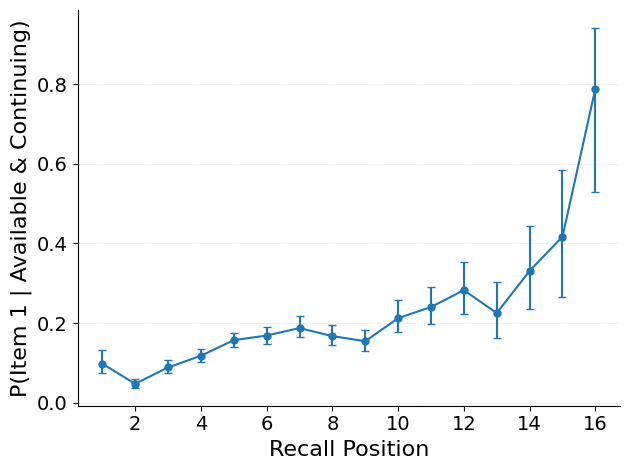

In [5]:
#| code-summary: Plot nth-item recall curve
#| label: fig-nth-item-recall
#| fig-cap: "Nth-item recall curve for the first study position."
plotters = {
    "simple": plot_simple_nth_item_recall_curve,
    "conditional": plot_conditional_nth_item_recall_curve,
}
plotters[mode](
    datasets=data,
    trial_masks=trial_mask,
    query_study_position=query_study_position,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_conditional_nth_item_recall_curve)

---

### plot_conditional_nth_item_recall_curve

>      plot_conditional_nth_item_recall_curve (datasets:Union[Sequence[jaxcmr.ty
>                                              ping.RecallDataset],jaxcmr.typing
>                                              .RecallDataset], trial_masks:Unio
>                                              n[Sequence[jaxtyping.Bool[Array,'
>                                              trial_count']],jaxtyping.Bool[Arr
>                                              ay,'trial_count']],
>                                              query_study_position:int=0, color
>                                              _cycle:Optional[list[str]]=None, 
>                                              labels:Optional[Sequence[str]]=No
>                                              ne,
>                                              contrast_name:Optional[str]=None,
>                                              axis:Optional[matplotlib.axes._ax
>                                              es.Axes]=None,
>                                              confidence_level:float=0.95)

*Plot conditional nth-item recall curve.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| query_study_position | int | 0 | 0-based study position to analyze. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the recall curve.** |

In [7]:
#| echo: false
show_doc(plot_simple_nth_item_recall_curve)

---

### plot_simple_nth_item_recall_curve

>      plot_simple_nth_item_recall_curve (datasets:Union[Sequence[jaxcmr.typing.
>                                         RecallDataset],jaxcmr.typing.RecallDat
>                                         aset], trial_masks:Union[Sequence[jaxt
>                                         yping.Bool[Array,'trial_count']],jaxty
>                                         ping.Bool[Array,'trial_count']],
>                                         query_study_position:int=0,
>                                         color_cycle:Optional[list[str]]=None,
>                                         labels:Optional[Sequence[str]]=None,
>                                         contrast_name:Optional[str]=None, axis
>                                         :Optional[matplotlib.axes._axes.Axes]=
>                                         None, confidence_level:float=0.95)

*Plot simple nth-item recall curve.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| query_study_position | int | 0 | 0-based study position to analyze. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the recall curve.** |

### Computation functions

In [8]:
#| echo: false
show_doc(conditional_nth_item_recall_curve)

---

### conditional_nth_item_recall_curve

>      conditional_nth_item_recall_curve (dataset:jaxcmr.typing.RecallDataset,
>                                         query_study_position:int=0)

*Nth-item recall conditioned on availability and prior recall.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| query_study_position | int | 0 | 0-based study position to analyze. |
| **Returns** | **Float[Array, 'recall_positions']** |  | **Conditional probability at each output position.** |

In [9]:
# Item 1 is recalled at position 1 or 2; conditional prob is 0.5 then 1.0
def _make_dataset(recalls, presentations):
    n_trials = recalls.shape[0]
    list_length = presentations.shape[1]
    return {
        "subject": jnp.ones((n_trials, 1), dtype=jnp.int32),
        "listLength": jnp.full((n_trials, 1), list_length, dtype=jnp.int32),
        "pres_itemnos": presentations,
        "recalls": recalls,
    }

dataset = _make_dataset(
    jnp.array([[1, 2, 3], [2, 1, 3]]),
    jnp.array([[1, 2, 3], [1, 2, 3]]),
)
curve = conditional_nth_item_recall_curve(dataset)
assert jnp.allclose(curve[:2], jnp.array([0.5, 1.0]))
assert jnp.isnan(curve[2])

In [10]:
#| echo: false
show_doc(simple_nth_item_recall_curve)

---

### simple_nth_item_recall_curve

>      simple_nth_item_recall_curve (dataset:jaxcmr.typing.RecallDataset,
>                                    query_study_position:int=0)

*Recall-position probability of the queried study item.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| query_study_position | int | 0 | 0-based study position to analyze. |
| **Returns** | **Float[Array, 'recall_positions']** |  | **Probability at each recall output position.** |

In [11]:
# Simple curve: 50% chance at positions 1 and 2, 0% at position 3
curve = simple_nth_item_recall_curve(dataset)
assert jnp.allclose(curve, jnp.array([0.5, 0.5, 0.0]))